# Fase 3 — Análise dos Dados e Camada Gold

In [350]:
import banco
import pandas as pd
import matplotlib.pyplot as plt

In [351]:
conexao = banco.conectar()

Conexao Bem Sucedida


### 1.1 Quais são os 5 órgãos com maior custo total?

Para identificar os órgãos com maior custo total, os registros da tabela `silver_viagem` serão agrupados pelo campo `nome_orgao_superior`.

O custo total de cada órgão será calculado pela soma do campo `valor_total`, sendo selecionados os cinco órgãos com os maiores valores.

In [352]:
sql = """
    SELECT
        nome_orgao_superior,
        SUM(valor_total) AS custo_total
    FROM silver_viagem
    GROUP BY nome_orgao_superior
    ORDER BY custo_total DESC
    LIMIT 5;
"""

In [353]:
cursor = conexao.cursor()

cursor.execute(sql)

resultados = cursor.fetchall()

cursor.close()

In [354]:
df_orgao = pd.DataFrame(
    resultados,
    columns=["nome_orgao_superior", "custo_total"]
)

df_orgao

,nome_orgao_superior,custo_total
0,Ministério da Justiça e Segurança Pública,486933121.65
1,Ministério da Defesa,156070304.49
2,Ministério da Educação,111291349.34
3,Ministério do Meio Ambiente e Mudança do Clima,49697710.16
4,Ministério da Previdência Social,40417309.06


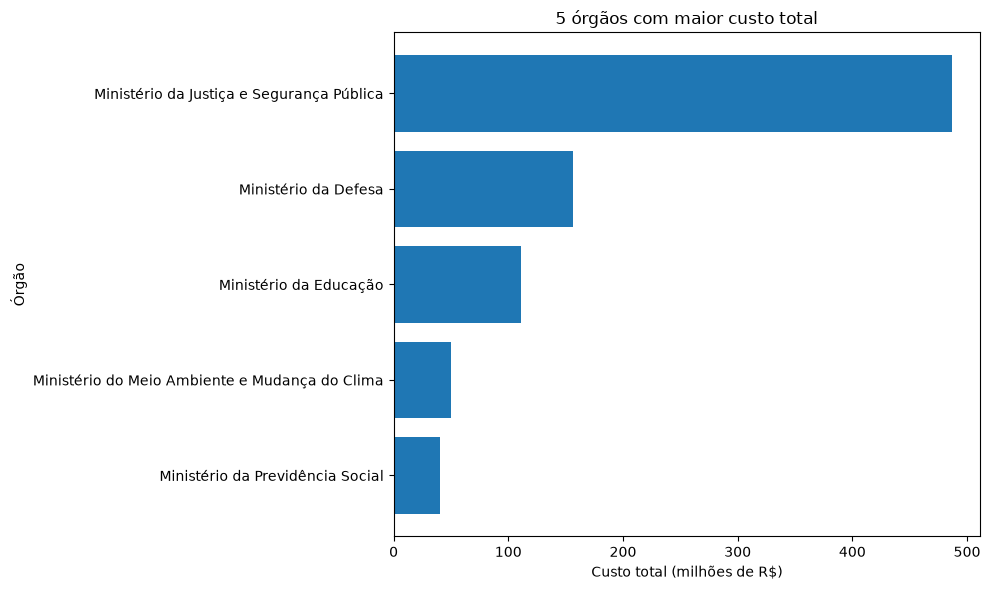

In [355]:
plt.figure(figsize=(10, 6))

plt.barh(
    df_orgao["nome_orgao_superior"],
    df_orgao["custo_total"]/1000000
)

plt.xlabel("Custo total (milhões de R$)")
plt.ylabel("Órgão")
plt.title("5 órgãos com maior custo total")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

#### Resultado

Os resultados mostram os cinco órgãos com os maiores custos totais de viagens. O Ministério da Justiça e Segurança Pública apresenta o maior valor, seguido pelos Ministérios da Defesa, da Educação, do Meio Ambiente e Mudança do Clima e da Previdência Social.

### 1.2 Qual tipo de pagamento apresenta o maior valor médio?

Para identificar o tipo de pagamento com maior valor médio, os registros da tabela `silver_pagamento` foram agrupados pelo campo `tipo_pagamento`.

Em seguida, foi calculada a média dos valores para cada tipo de pagamento, sendo selecionado aquele que apresentou a maior média.

In [356]:
sql = """
    SELECT 
	    tipo_pagamento,
	    ROUND(AVG(valor),2) as media_valor
    FROM silver_pagamento

    GROUP BY tipo_pagamento
    ORDER BY AVG(valor) DESC
    LIMIT 5
    """

In [357]:
cursor = conexao.cursor()
cursor.execute(sql)
resultados = cursor.fetchall()
cursor.close()

df_pagamento = pd.DataFrame(
    resultados,
    columns=["tipo_pagamento", "media_valor"]
)

df_pagamento

,tipo_pagamento,media_valor
0,DIÁRIAS,2078.28
1,PASSAGEM,1878.34
2,Serviço correlato: seguro,447.51
3,RESTITUIÇÃO,245.70


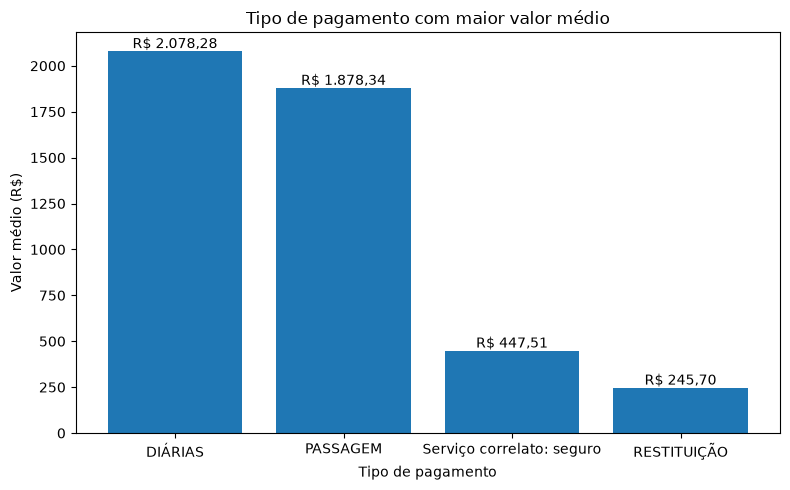

In [358]:
plt.figure(figsize=(8, 5))

barra = plt.bar(
    df_pagamento["tipo_pagamento"],
    df_pagamento["media_valor"]
)

plt.xlabel("Tipo de pagamento")
plt.ylabel("Valor médio (R$)")
plt.title("Tipo de pagamento com maior valor médio")

for b in barra:
    valor = b.get_height()
    plt.text(
        b.get_x() + b.get_width() / 2,
        valor,
        f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

#### Resultado

A análise indica que o tipo de pagamento **DIÁRIAS** apresenta o maior valor médio, com uma média de **R$ 2.078,28** por pagamento.

### 1.3 Qual é o meio de transporte mais utilizado nos trechos?

Para identificar o meio de transporte mais utilizado, os registros da tabela `silver_trecho` foram agrupados pelo campo `meio_transporte`.

Em seguida, foi contabilizada a quantidade de trechos para cada meio de transporte e os resultados foram ordenados de forma decrescente, permitindo identificar o meio de transporte com maior utilização.

In [359]:
sql = """
    SELECT 
    	meio_transporte,
	    Count(*) AS contagem_utilizacao
    FROM silver_trecho

    GROUP BY meio_transporte
    ORDER BY contagem_utilizacao DESC
    """

In [360]:
cursor = conexao.cursor()
cursor.execute(sql)
resultados = cursor.fetchall()
cursor.close()

df_transporte = pd.DataFrame(
    resultados,
    columns=["meio_transporte", "contagem_utilizacao"]
)

df_transporte

,meio_transporte,contagem_utilizacao
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


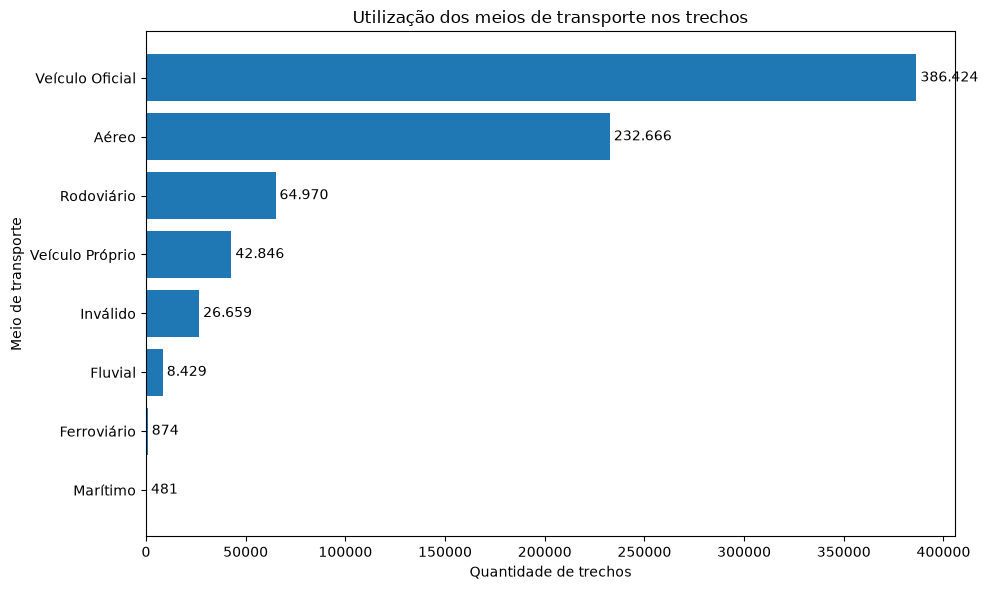

In [361]:
plt.figure(figsize=(10, 6))

barras = plt.barh(
    df_transporte["meio_transporte"],
    df_transporte["contagem_utilizacao"]
)

plt.xlabel("Quantidade de trechos")
plt.ylabel("Meio de transporte")
plt.title("Utilização dos meios de transporte nos trechos")

plt.gca().invert_yaxis()

for barra in barras:
    valor = barra.get_width()
    plt.text(
        valor,
        barra.get_y() + barra.get_height() / 2,
        f" {int(valor):,}".replace(",", "."),
        va="center"
    )

plt.tight_layout()
plt.show()

#### Resultado

O **Veículo Oficial** foi o meio de transporte mais utilizado nos trechos analisados, com **386.424 registros**, seguido pelo transporte **Aéreo**, com **232.666 registros**. O transporte **Rodoviário** apresentou 64.970 ocorrências, enquanto o **Veículo Próprio** apresentou 42.846.

Também foram identificados 26.659 registros classificados como **"Inválido"**, além dos meios **Fluvial**, **Ferroviário** e **Marítimo**, que apresentaram quantidades menores de utilização.

### 1.4 Qual órgão pagou mais no total?

Para identificar o órgão que realizou o maior volume de pagamentos, os registros da tabela `silver_pagamento` foram agrupados pelo campo `nome_orgao_pagador`.

Em seguida, foi calculada a soma dos valores pagos por cada órgão, permitindo identificar aquele que apresentou o maior total.

In [362]:
sql = """
    SELECT
        nome_orgao_pagador,
        SUM(valor) AS total_pago
    FROM silver_pagamento
    GROUP BY nome_orgao_pagador
    ORDER BY total_pago DESC
    LIMIT 10
    """

In [363]:
cursor = conexao.cursor()
cursor.execute(sql)
resultados = cursor.fetchall()
cursor.close()

df_transporte = pd.DataFrame(
    resultados,
    columns=["nome_orgao_pagador", "total_pago"]
)

df_transporte

,nome_orgao_pagador,total_pago
0,Fundo Nacional de Segurança Pública,278481047.89
1,Sigiloso,200484801.68
2,Comando da Aeronáutica,81769144.77
3,Instituto Nacional do Seguro Social,37427601.45
4,Comando do Exército,36872643.95
5,Ministério da Gestão e da Inovação em Serviços...,35541760.71
6,Instituto Brasileiro do Meio Ambiente e dos Re...,31589853.15
7,Ministério das Relações Exteriores - Unidades ...,25605376.38
8,Receita Federal do Brasil,23811027.00
9,Ministério da Agricultura e Pecuária - Unidade...,22899880.25


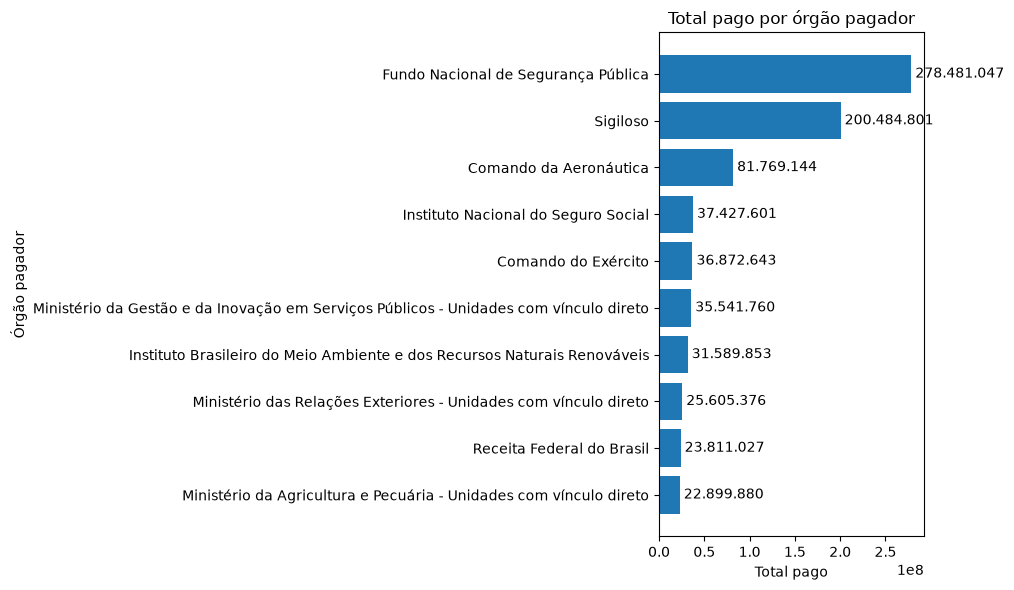

In [364]:
plt.figure(figsize=(10, 6))

barras = plt.barh(
    df_transporte["nome_orgao_pagador"],
    df_transporte["total_pago"]
)

plt.xlabel("Total pago")
plt.ylabel("Órgão pagador")
plt.title("Total pago por órgão pagador")

plt.gca().invert_yaxis()

for barra in barras:
    valor = barra.get_width()
    plt.text(
        valor,
        barra.get_y() + barra.get_height() / 2,
        f" {int(valor):,}".replace(",", "."),
        va="center"
    )

plt.tight_layout()
plt.show()

#### Resultado

O **Fundo Nacional de Segurança Pública** apresentou o maior total de pagamentos registrados, com **R$ 278,5 milhões**.

O segundo maior valor corresponde à categoria **"Sigiloso"**, com aproximadamente **R$ 200,5 milhões**.

## 2. Construção da Camada Gold

Nesta etapa, será construída uma camada Gold a partir da integração dos dados tratados na camada Silver.

As informações serão relacionadas por meio do campo `id_viagem` e agregadas conforme a necessidade de cada análise. Além da tabela Gold, será criada uma `VIEW` com a mesma lógica, permitindo consultar os dados agregados sem duplicar fisicamente os registros.

As consultas da camada Gold serão utilizadas para responder às seguintes questões:

- A viagem de maior duração e seu custo total?
- Qual UF de destino aparece em mais trechos?
- Quais são os 3 destinos com maior custo médio por viagem?

### 2.1 Gold — Duração e custo das viagens

A primeira tabela Gold contém informações de cada viagem, considerando sua duração e seu custo total.

Essa estrutura será utilizada para identificar a viagem de maior duração e analisar seu respectivo custo total.

In [365]:
sql_gold_viagem = """
DROP VIEW IF EXISTS vw_gold_viagem_duracao;
DROP TABLE IF EXISTS gold_viagem_duracao;


CREATE TABLE gold_viagem_duracao AS
SELECT 
    id_viagem,
    duracao_dias,
    valor_total
FROM silver_viagem
ORDER BY duracao_dias DESC;
"""

cursor = conexao.cursor()
cursor.execute(sql_gold_viagem)
conexao.commit()
cursor.close()

### 2.2 Gold — Informações dos trechos

A segunda tabela Gold integra os dados de `silver_trecho` com as informações de custo de `silver_viagem`.

Além das informações de origem e destino de cada trecho, são calculadas a quantidade de trechos de cada viagem e a média do custo total da viagem por trecho.

Essa estrutura será utilizada nas análises relacionadas aos destinos e aos trechos das viagens.

In [366]:
sql_gold_trechos = """
DROP VIEW IF EXISTS vw_gold_trechos_viagem;
DROP TABLE IF EXISTS gold_trechos_viagem;

CREATE TABLE gold_trechos_viagem AS

WITH n_trecho AS (
	SELECT 
		id_viagem,
		COUNT(*) AS qtd_trechos
	FROM silver_trecho

	GROUP BY id_viagem
)
SELECT 
	t.id_viagem,
	t.id_trecho,
	t.origem_uf,
	t.origem_cidade,
	t.destino_uf,
	t.destino_cidade,
	v.valor_total,
	n.qtd_trechos,
	ROUND(v.valor_total/n.qtd_trechos,2) AS media_valor_trecho
	
FROM silver_trecho t

LEFT JOIN n_trecho n
	ON n.id_viagem = t.id_viagem

LEFT JOIN silver_viagem v
	ON v.id_viagem = t.id_viagem
"""

cursor = conexao.cursor()
cursor.execute(sql_gold_trechos)
conexao.commit()
cursor.close()

### 2.3 Criação das Views

Além das tabelas Gold, serão criadas Views com as mesmas informações. As Views permitem consultar os dados estruturados da camada Gold sem a necessidade de duplicar fisicamente os dados no banco.

Dessa forma, as tabelas armazenam os resultados consolidados, enquanto as Views fornecem uma forma alternativa de consulta para as análises.

In [367]:
sql_view_viagem = """
CREATE OR REPLACE VIEW vw_gold_viagem_duracao AS
SELECT 
    id_viagem,
    duracao_dias,
    valor_total
FROM gold_viagem_duracao;
"""

cursor = conexao.cursor()
cursor.execute(sql_view_viagem)
conexao.commit()
cursor.close()

In [368]:
sql_view_trechos = """
CREATE OR REPLACE VIEW vw_gold_trechos_viagem AS
SELECT 
    id_viagem,
    id_trecho,
    origem_uf,
    origem_cidade,
    destino_uf,
    destino_cidade,
    valor_total,
    qtd_trechos,
    media_valor_trecho
FROM gold_trechos_viagem;
"""

cursor = conexao.cursor()
cursor.execute(sql_view_trechos)
conexao.commit()
cursor.close()

### 2.4 A viagem de maior duração e seu custo total?

Para identificar a viagem de maior duração, os dados da tabela `gold_viagem_duracao` foram ordenados de forma decrescente pelo campo `duracao_dias`.

Em seguida, foi selecionado os 5 primeiros registros, permitindo identificar a viagem de maior duração e seu respectivo custo total.

In [369]:
sql = """
SELECT 
    id_viagem,
    duracao_dias,
    valor_total
FROM gold_viagem_duracao
ORDER BY duracao_dias DESC
LIMIT 5;
"""

In [370]:
cursor = conexao.cursor()
cursor.execute(sql)
resultados = cursor.fetchall()
cursor.close()

df_maior_viagem = pd.DataFrame(
    resultados,
    columns=[
        "id_viagem",
        "duracao_dias",
        "valor_total"
    ]
)

df_maior_viagem

,id_viagem,duracao_dias,valor_total
0,0000000000020699856,383,0.00
1,0000000000020793594,378,120650.00
2,0000000000020793492,369,113382.50
3,0000000000020774569,369,0.00
4,0000000000020685666,366,124312.50


#### Resultado

A viagem **20699856** apresentou a maior duração, com **383 dias**, e valor total de **R$ 0,00**.
O valor de **R$ 0,00** indica que não houve custos registrados para essa viagem nos campos utilizados no cálculo do `valor_total`.

### 2.5 Qual UF de destino aparece em mais trechos?

Para identificar a UF de destino mais frequente, os registros da tabela `gold_trechos_viagem` foram agrupados pelo campo `destino_uf`.

Em seguida, foi contabilizada a quantidade de trechos para cada UF e os resultados foram ordenados de forma decrescente.

In [371]:
sql = """
SELECT 
    destino_uf,
    COUNT(*) AS qtd_trechos
FROM gold_trechos_viagem
WHERE destino_uf IS NOT NULL
GROUP BY destino_uf
ORDER BY qtd_trechos DESC;
"""

In [372]:
cursor = conexao.cursor()
cursor.execute(sql)
resultados = cursor.fetchall()
cursor.close()

df_destino_uf = pd.DataFrame(
    resultados,
    columns=[
        "destino_uf",
        "qtd_trechos"
    ]
)

df_destino_uf

,destino_uf,qtd_trechos
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603
5,Pará,40044
6,Rio Grande do Sul,38684
7,Mato Grosso do Sul,30516
8,Bahia,28375
9,Pernambuco,28372


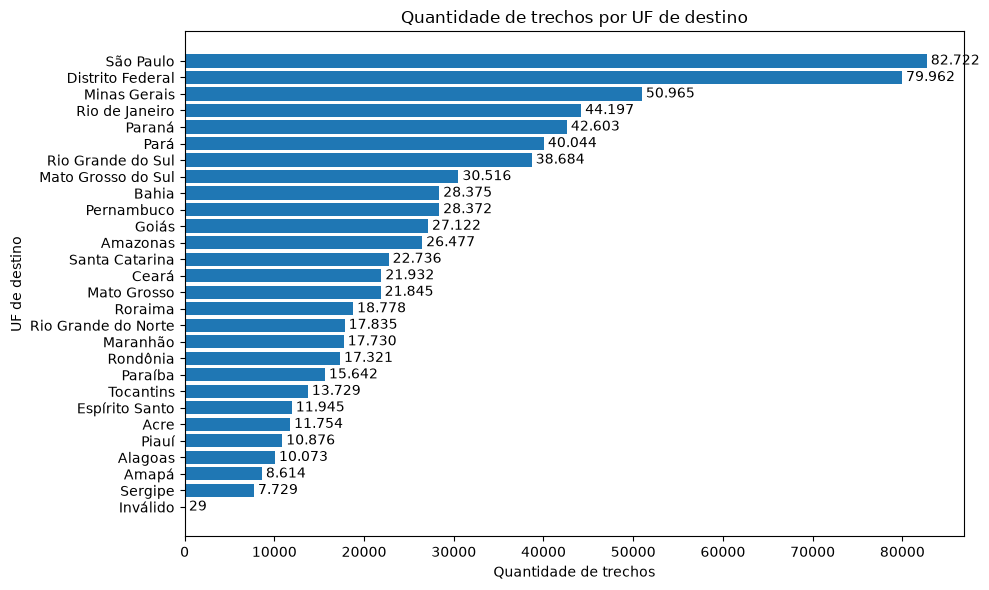

In [373]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

barras = plt.barh(
    df_destino_uf["destino_uf"],
    df_destino_uf["qtd_trechos"]
)

plt.xlabel("Quantidade de trechos")
plt.ylabel("UF de destino")
plt.title("Quantidade de trechos por UF de destino")

plt.gca().invert_yaxis()

for barra in barras:
    valor = barra.get_width()
    plt.text(
        valor,
        barra.get_y() + barra.get_height() / 2,
        f" {int(valor):,}".replace(",", "."),
        va="center"
    )

plt.tight_layout()
plt.show()

#### Resultado

A **UF de destino com maior quantidade de trechos foi São Paulo**, com **82.722 registros**, seguida pelo **Distrito Federal**, com **79.962 trechos**.

### 2.5 Quais são os 3 destinos com maior custo médio por viagem?

Para responder a essa questão, serão utilizadas duas abordagens de cálculo.

A primeira considera diretamente o custo total das viagens e calcula sua média para cada destino. Essa abordagem segue diretamente o enunciado, mas pode ser influenciada por viagens que possuem múltiplos destinos.

A segunda utiliza o campo `media_valor_trecho`, que distribui o custo total da viagem pela quantidade de trechos realizados. Dessa forma, busca-se reduzir a influência da quantidade de trechos sobre o custo associado a cada destino.

In [374]:
sql = """
SELECT
    destino_uf,
    ROUND(AVG(valor_total), 2) AS custo_medio_viagem
FROM gold_trechos_viagem
WHERE destino_uf IS NOT NULL
GROUP BY destino_uf
ORDER BY custo_medio_viagem DESC
LIMIT 3;
"""

In [375]:

cursor = conexao.cursor()
cursor.execute(sql)
resultados = cursor.fetchall()
cursor.close()

df_custo_medio = pd.DataFrame(
    resultados,
    columns=[
        "destino_uf",
        "custo_medio_viagem"
    ]
)

df_custo_medio

,destino_uf,custo_medio_viagem
0,Roraima,29627.50
1,Rondônia,16903.42
2,Acre,16729.42


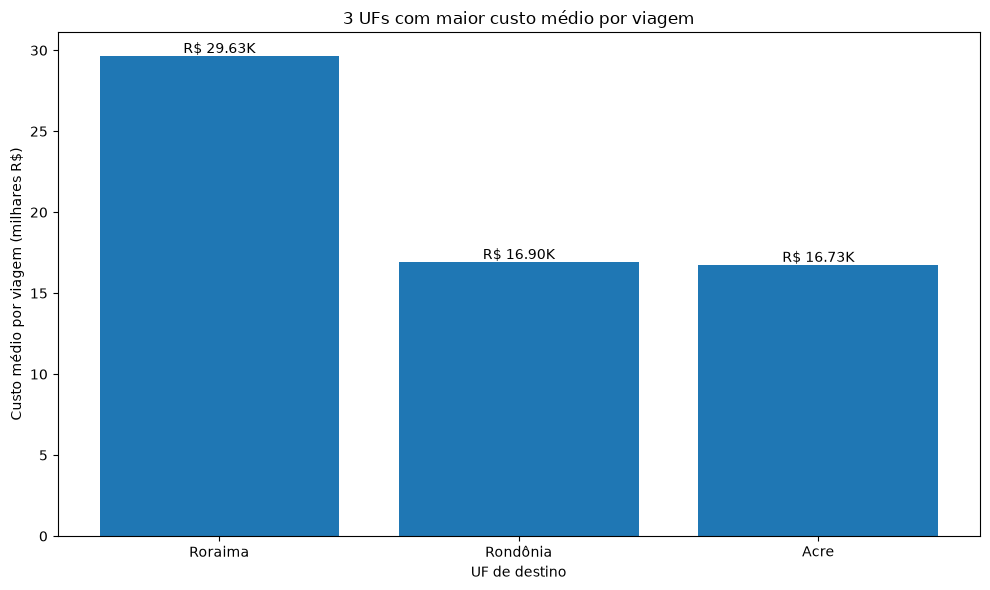

In [376]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

barras = plt.bar(
    df_custo_medio["destino_uf"],
    df_custo_medio["custo_medio_viagem"] / 1_000
)

plt.xlabel("UF de destino")
plt.ylabel("Custo médio por viagem (milhares R$)")
plt.title("3 UFs com maior custo médio por viagem")

for barra in barras:
    valor = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor,
        f"R$ {valor:.2f}K",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [377]:
sql = """
SELECT
    destino_uf,
    ROUND(AVG(media_valor_trecho), 2) AS custo_medio_trecho
FROM gold_trechos_viagem
WHERE destino_uf IS NOT NULL
GROUP BY destino_uf
ORDER BY custo_medio_trecho DESC
LIMIT 3;
"""

In [378]:

cursor = conexao.cursor()
cursor.execute(sql)
resultados = cursor.fetchall()
cursor.close()

df_custo_trecho = pd.DataFrame(
    resultados,
    columns=[
        "destino_uf",
        "custo_medio_trecho"
    ]
)

df_custo_trecho

,destino_uf,custo_medio_trecho
0,Inválido,3113.05
1,Distrito Federal,2742.42
2,Roraima,2346.35


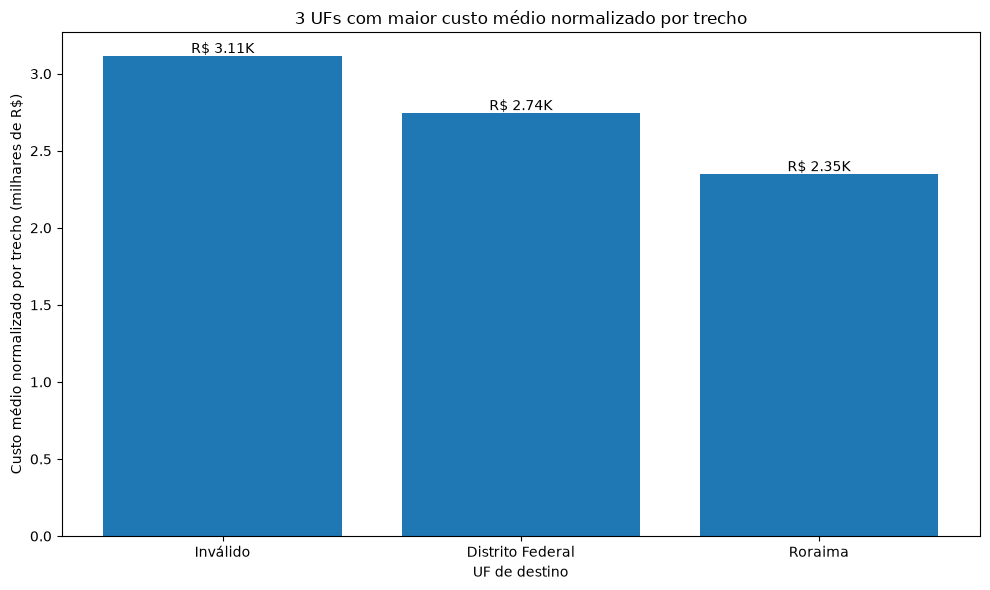

In [379]:
plt.figure(figsize=(10, 6))

barras = plt.bar(
    df_custo_trecho["destino_uf"],
    df_custo_trecho["custo_medio_trecho"] / 1_000
)

plt.xlabel("UF de destino")
plt.ylabel("Custo médio normalizado por trecho (milhares de R$)")
plt.title("3 UFs com maior custo médio normalizado por trecho")

for barra in barras:
    valor = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor,
        f"R$ {valor:.2f}K",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

#### Resultado

Na primeira abordagem, considerando diretamente o custo total médio das viagens associadas a cada UF, **Roraima** apresentou o maior valor, com **R$ 29.627,50**, seguida por **Rondônia**, com **R$ 16.903,42**, e **Acre**, com **R$ 16.729,42**.

Na segunda abordagem, considerando o custo médio normalizado pela quantidade de trechos, os maiores valores foram observados nos registros com destino **"Inválido"**, com **R$ 3.113,05**, no **Distrito Federal**, com **R$ 2.742,42**, e em **Roraima**, com **R$ 2.346,35**.

A diferença entre os resultados ocorre porque a primeira abordagem considera o custo total das viagens, enquanto a segunda distribui esse custo pela quantidade de trechos realizados. Dessa forma, as duas métricas oferecem perspectivas diferentes sobre o custo associado aos destinos.

## 3. Validação das Views

As Views criadas serão consultadas para verificar se estão disponíveis no banco de dados e se retornam corretamente os mesmos dados das respectivas tabelas Gold.

In [380]:
sql = """
SELECT * FROM vw_gold_viagem_duracao LIMIT 5;
"""

In [381]:
cursor = conexao.cursor()
cursor.execute(sql)
resultados = cursor.fetchall()
cursor.close()

pd.DataFrame(
    resultados,
    columns=["id_viagem", "duracao_dias", "valor_total"]
)

,id_viagem,duracao_dias,valor_total
0,0000000000020699856,383,0.00
1,0000000000020793594,378,120650.00
2,0000000000020793492,369,113382.50
3,0000000000020774569,369,0.00
4,0000000000020685666,366,124312.50


In [382]:
sql = """
SELECT * FROM vw_gold_trechos_viagem LIMIT 5;
"""

In [383]:
cursor = conexao.cursor()
cursor.execute(sql)
resultados = cursor.fetchall()
cursor.close()

pd.DataFrame(
    resultados,
    columns=[
        "id_viagem",
        "id_trecho",
        "origem_uf",
        "origem_cidade",
        "destino_uf",
        "destino_cidade",
        "valor_total",
        "qtd_trechos",
        "media_valor_trecho"
    ]
)

,id_viagem,id_trecho,origem_uf,origem_cidade,destino_uf,destino_cidade,valor_total,qtd_trechos,media_valor_trecho
0,0000000000020261730,1,Rio de Janeiro,Niterói,Rio de Janeiro,Rio de Janeiro,0.00,4,0.00
1,0000000000020261730,2,Distrito Federal,Brasília,Acre,Rio Branco,0.00,4,0.00
2,0000000000020261730,3,Rio de Janeiro,Rio de Janeiro,Distrito Federal,Brasília,0.00,4,0.00
3,0000000000020261730,4,Acre,Rio Branco,Rio de Janeiro,Niterói,0.00,4,0.00
4,0000000000020289421,7,NaN,Bogotá,Minas Gerais,Uberlândia,5569.81,2,2784.91


## 4. Conclusão

A análise permitiu responder às questões de negócio propostas, utilizando os dados tratados na camada Silver e estruturados na camada Gold.